In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/all unlabeled/oral_normal_3080.jpg
/kaggle/input/all unlabeled/oral_normal_3357.jpg
/kaggle/input/all unlabeled/oral_normal_0983.jpg
/kaggle/input/all unlabeled/oral_normal_1124.jpg
/kaggle/input/all unlabeled/oral_normal_3829.jpg
/kaggle/input/all unlabeled/oral_normal_3515.jpg
/kaggle/input/all unlabeled/oral_normal_1324.jpg
/kaggle/input/all unlabeled/oral_normal_4162.jpg
/kaggle/input/all unlabeled/oral_scc_0771.jpg
/kaggle/input/all unlabeled/oral_scc_0707.jpg
/kaggle/input/all unlabeled/oral_scc_3093.jpg
/kaggle/input/all unlabeled/oral_normal_0952.jpg
/kaggle/input/all unlabeled/oral_normal_4147.jpg
/kaggle/input/all unlabeled/oral_scc_0480.jpg
/kaggle/input/all unlabeled/oral_scc_0654.jpg
/kaggle/input/all unlabeled/oral_normal_1627.jpg
/kaggle/input/all unlabeled/oral_scc_0620.jpg
/kaggle/input/all unlabeled/oral_normal_1034.jpg
/kaggle/input/all unlabeled/oral_scc_3567.jpg
/kaggle/input/all unlabeled/oral_scc_1208.jpg
/kaggle/input/all unlabeled/oral_scc_0761.jp

In [2]:
!pip install torch torchvision matplotlib numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [5]:
! pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=22bd01840c994b68e39cc90f2aa7bdfcf722b19bc8a41cbf74ac75d37c70dc15
  Stored in directory: /root/.cache/pip/wheels/8b/6f/9b/231a832f811ab6ebb1b32455b177ffc6b8b1cd8de19de70c09
Successfully built efficientnet_pytorch


In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from torch.cuda.amp import autocast, GradScaler
import os
import torch.optim as optim
from efficientnet_pytorch import EfficientNet  # pip install efficientnet_pytorch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [7]:
# Set environment to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [8]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [9]:
class OralCancerDataset(Dataset):
    def __init__(self, image_paths, transform1, transform2):
        self.image_paths = image_paths
        self.transform1 = transform1
        self.transform2 = transform2

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        view1 = self.transform1(image)
        view2 = self.transform2(image)
        return view1, view2

In [10]:
# Define wrapper for downstream task (single image + label) - Simplified since base uses None transform
class DownstreamWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        item = self.subset[idx]
        if len(item) == 3:  # From aug dataset, ignore img2
            img, _, label = item
        else:  # From base (PIL, label)
            img, label = item
        if self.transform:
            img = self.transform(img)
        return img, label

In [11]:
# Projector MLP
class Projector(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = base_encoder
        self.encoder.classifier = nn.Identity()  # Remove the final classifier to get 1280 features
        self.feature_dim = 1280  # EfficientNet-B0 feature dim after avgpool
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)  # (batch, 1280)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)  # L2 normalization

In [13]:
# DCL Loss Function
def dcl_loss(features, temperature=0.2, device='cuda'):  # Updated tau=0.2 as per paper
    # features: (2*batch_size, projection_dim), assumed L2-normalized
    batch_size = features.shape[0] // 2
    features = F.normalize(features, dim=1)  # Ensure normalized
    sim = torch.matmul(features, features.T) / temperature  # Similarity matrix

    # Positive mask (off-diagonal for paired views)
    pos_mask = torch.zeros_like(sim, dtype=torch.bool).to(device)
    pos_mask[0:batch_size, batch_size:] = torch.eye(batch_size, dtype=torch.bool).to(device)
    pos_mask[batch_size:, 0:batch_size] = torch.eye(batch_size, dtype=torch.bool).to(device)

    # Diagonal mask (self-similarities)
    diag_mask = torch.eye(features.shape[0], dtype=torch.bool).to(device)

    # Full mask for negatives: exclude self and positives
    neg_mask = ~(diag_mask | pos_mask)

    # Positive similarities per anchor (2*batch_size values)
    pos_sim = torch.masked_select(sim, pos_mask).view(-1)  # Fixed to -1 for correct shape

    # Mask sim for negatives only (set excluded to -inf for logsumexp)
    sim_neg = sim.clone()
    sim_neg[~neg_mask] = -float('inf')

    # Log sum exp over negatives for each anchor
    log_u = torch.logsumexp(sim_neg, dim=1)

    # DCL loss: average over all anchors
    loss = (-pos_sim + log_u).mean()
    return loss

In [14]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

downstream_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [17]:
# Define OralCancerSimCLRDataset (assumed based on usage)
class OralCancerSimCLRDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.image_paths = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.jpg')]
        self.labels = [0 if 'normal' in os.path.basename(p) else 1 for p in self.image_paths]  # 0=Non-Cancer, 1=Cancer

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img1 = self.transform(image)
            img2 = self.transform(image) if self.transform else image
            return img1, img2, label
        return image, label

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Found 10002 images


In [18]:
# Load dataset for pre-training (with aug)
data_path = '/kaggle/input/all unlabeled'
if not os.path.exists(data_path):
    raise ValueError(f"Data path {data_path} does not exist. Run '!ls /kaggle/input/' to check.")
print(f"Loading dataset from {data_path}")

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Loading dataset from /kaggle/input/all unlabeled
Found 10002 images


In [20]:
# Split indices
pretrain_size = int(0.8 * len(aug_dataset))  # ~8001
remaining_size = len(aug_dataset) - pretrain_size  # ~2001
pretrain_split, remaining_split = random_split(aug_dataset, [pretrain_size, remaining_size])
pretrain_indices = pretrain_split.indices
remaining_indices = remaining_split.indices
print(f"Pretrain dataset size: {len(pretrain_indices)}")
print(f"Remaining dataset size: {len(remaining_indices)}")

Pretrain dataset size: 8001
Remaining dataset size: 2001


In [21]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [22]:
# Create base dataset without transform (for downstream, t-SNE, test - PIL images)
base_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=None)

In [23]:
# Downstream dataset (same 80% indices, but from base)
downstream_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
downstream_dataset = DownstreamWrapper(downstream_subset, downstream_transform)
train_size = int(0.7 * len(downstream_dataset))  # ~5601
val_size = len(downstream_dataset) - train_size  # ~2400
downstream_train_split, downstream_val_split = random_split(downstream_dataset, [train_size, val_size])

In [24]:
# Downstream loaders
train_loader_downstream = DataLoader(downstream_train_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader_downstream = DataLoader(downstream_val_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [25]:
# Test loader (20% holdout from base)
test_subset = torch.utils.data.Subset(base_dataset, remaining_indices)
test_dataset = DownstreamWrapper(test_subset, downstream_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [26]:
# Initialize SimCLR model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_encoder = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model = SimCLR(base_encoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scaler = torch.amp.GradScaler(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


In [27]:
# Clear GPU cache before training (Fix OOM)
torch.cuda.empty_cache()

In [28]:
# Pre-training loop (modified to use dcl_loss instead of nt_xent_loss)
num_epochs = 10
pretrain_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Pretrain Epoch {epoch+1}/{num_epochs}"):
        img1, img2, _ = batch
        img1, img2 = img1.to(device), img2.to(device)
        optimizer.zero_grad()
        with autocast():  # Mixed precision to save memory
            z1 = model(img1)
            z2 = model(img2)
            features = torch.cat([z1, z2], dim=0)  # Concatenate for DCL
            loss = dcl_loss(features, temperature=0.2, device=device)  # Replaced nt_xent_loss with dcl_loss
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    torch.cuda.empty_cache()  # Clear cache after each epoch

Pretrain Epoch 1/10:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipykernel_36/1391320762.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed precision to save memory
Pretrain Epoch 1/10: 100%|██████████| 250/250 [01:58<00:00,  2.11it/s]


Epoch 1, Loss: 0.6696


Pretrain Epoch 2/10: 100%|██████████| 250/250 [01:44<00:00,  2.38it/s]


Epoch 2, Loss: -0.2957


Pretrain Epoch 3/10: 100%|██████████| 250/250 [01:44<00:00,  2.39it/s]


...

Epoch 8, Loss: -0.6899


Pretrain Epoch 9/10: 100%|██████████| 250/250 [01:42<00:00,  2.43it/s]


Epoch 9, Loss: -0.7122


Pretrain Epoch 10/10: 100%|██████████| 250/250 [01:38<00:00,  2.53it/s]

Epoch 10, Loss: -0.7242


In [29]:
# Save pretrained model
torch.save(model.state_dict(), 'simclr_pretask_efficientnetb0.pth')

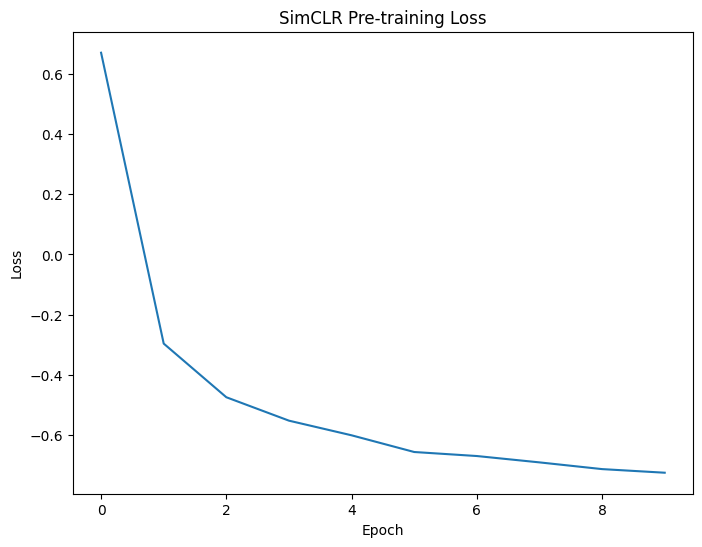

In [30]:
# Plot pre-training loss
plt.figure(figsize=(8, 6))
plt.plot(pretrain_losses)
plt.title('SimCLR Pre-training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('pretrain_loss.png')
plt.show()

In [31]:
# t-SNE Visualization
model.eval()

SimCLR(
  (encoder): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activa

Extracting features for t-SNE: 100%|██████████| 251/251 [00:26<00:00,  9.56it/s]


Running t-SNE on pretrain dataset features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 8001 samples in 0.004s...
[t-SNE] Computed neighbors for 8001 samples in 2.260s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8001
[t-SNE] Computed conditional probabilities for sample 2000 / 8001
[t-SNE] Computed conditional probabilities for sample 3000 / 8001
[t-SNE] Computed conditional probabilities for sample 4000 / 8001
[t-SNE] Computed conditional probabilities for sample 5000 / 8001
[t-SNE] Computed conditional probabilities for sample 6000 / 8001
[t-SNE] Computed conditional probabilities for sample 7000 / 8001
[t-SNE] Computed conditional probabilities for sample 8000 / 8001
[t-SNE] Computed conditional probabilities for sample 8001 / 8001
[t-SNE] Mean sigma: 7.394395
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.002457
[t-SNE] KL divergence after 1000 iterations: 0.746627


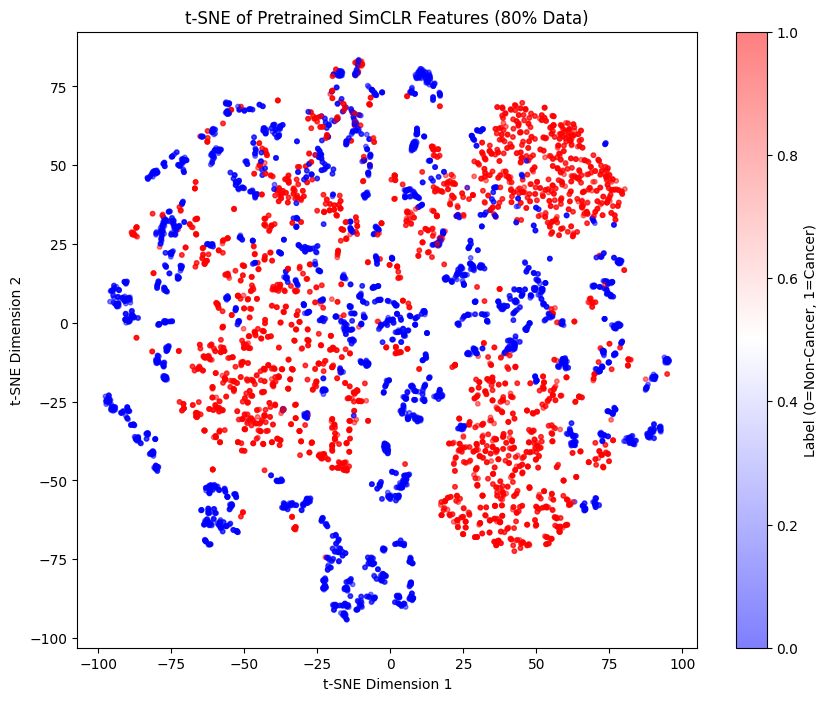

t-SNE plot saved as 'tsne_simclr_pretrain.png'


In [32]:
# Use base_dataset subset for t-SNE (PIL, then transform)
tsne_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
tsne_wrapper = DownstreamWrapper(tsne_subset, transform=downstream_transform)
tsne_loader = DataLoader(tsne_wrapper, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

features = []
labels = []
with torch.no_grad():
    for batch in tqdm(tsne_loader, desc="Extracting features for t-SNE"):
        img, label = batch  # Single img
        img = img.to(device)
        feature = model.encoder(img)
        feature = feature.view(feature.size(0), -1)
        features.append(feature.cpu().numpy())
        labels.append(label.numpy())
features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print("Running t-SNE on pretrain dataset features...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
tsne_features = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='bwr', alpha=0.5, s=10)
plt.colorbar(scatter, label='Label (0=Non-Cancer, 1=Cancer)')
plt.title('t-SNE of Pretrained SimCLR Features (80% Data)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('tsne_simclr_pretrain.png')
plt.show()
print("t-SNE plot saved as 'tsne_simclr_pretrain.png'")

In [33]:
# Downstream classification
num_epochs_cls = 10
classifier = nn.Sequential(
    model.encoder,
    nn.Linear(1280, 2)
).to(device)
for param in classifier[0].parameters():
    param.requires_grad = False  # Freeze encoder
optimizer_cls = torch.optim.Adam(classifier[1].parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
train_losses_cls, val_losses_cls = [], []
train_accs_cls, val_accs_cls = [], []

for epoch in range(num_epochs_cls):
    # Train
    classifier.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for img, label in tqdm(train_loader_downstream, desc=f"Downstream Epoch {epoch+1}/{num_epochs_cls}"):
        img, label = img.to(device), label.to(device)
        optimizer_cls.zero_grad()
        output = classifier(img)
        loss = criterion(output, label)
        loss.backward()
        optimizer_cls.step()
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += label.size(0)
        train_correct += predicted.eq(label).sum().item()
    train_losses_cls.append(train_loss / len(train_loader_downstream))
    train_accs_cls.append(train_correct / train_total)

    # Validate
    classifier.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for img, label in val_loader_downstream:
            img, label = img.to(device), label.to(device)
            output = classifier(img)
            loss = criterion(output, label)
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += label.size(0)
            val_correct += predicted.eq(label).sum().item()
    val_losses_cls.append(val_loss / len(val_loader_downstream))
    val_accs_cls.append(val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Loss {train_losses_cls[-1]:.4f}, Acc {train_accs_cls[-1]:.4f} | Val Loss {val_losses_cls[-1]:.4f}, Acc {val_accs_cls[-1]:.4f}")

Downstream Epoch 1/10: 100%|██████████| 175/175 [00:18<00:00,  9.38it/s]


Epoch 1: Train Loss 0.3793, Acc 0.8218 | Val Loss 0.2864, Acc 0.8696


Downstream Epoch 2/10: 100%|██████████| 175/175 [00:17<00:00,  9.79it/s]


Epoch 2: Train Loss 0.3015, Acc 0.8716 | Val Loss 0.2561, Acc 0.8850


Downstream Epoch 3/10: 100%|██████████| 175/175 [00:18<00:00,  9.47it/s]


...

Epoch 8: Train Loss 0.2189, Acc 0.9102 | Val Loss 0.2052, Acc 0.9121


Downstream Epoch 9/10: 100%|██████████| 175/175 [00:18<00:00,  9.69it/s]


Epoch 9: Train Loss 0.2183, Acc 0.9141 | Val Loss 0.1908, Acc 0.9258


Downstream Epoch 10/10: 100%|██████████| 175/175 [00:18<00:00,  9.50it/s]


Epoch 10: Train Loss 0.2082, Acc 0.9139 | Val Loss 0.1856, Acc 0.9237


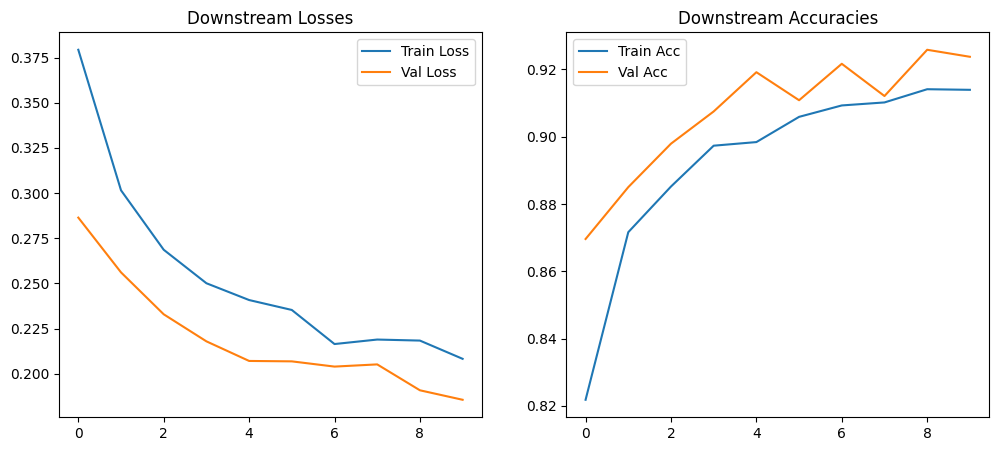

In [34]:
# Plot downstream losses and accuracies
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses_cls, label='Train Loss')
plt.plot(val_losses_cls, label='Val Loss')
plt.title('Downstream Losses')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs_cls, label='Train Acc')
plt.plot(val_accs_cls, label='Val Acc')
plt.title('Downstream Accuracies')
plt.legend()
plt.savefig('downstream_metrics.png')
plt.show()

In [35]:
# Test evaluation (optional)
classifier.eval()
test_correct, test_total = 0, 0
y_true, y_pred = [], []
with torch.no_grad():
    for img, label in test_loader:
        img, label = img.to(device), label.to(device)
        output = classifier(img)
        _, predicted = output.max(1)
        test_total += label.size(0)
        test_correct += predicted.eq(label).sum().item()
        y_true.extend(label.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9335


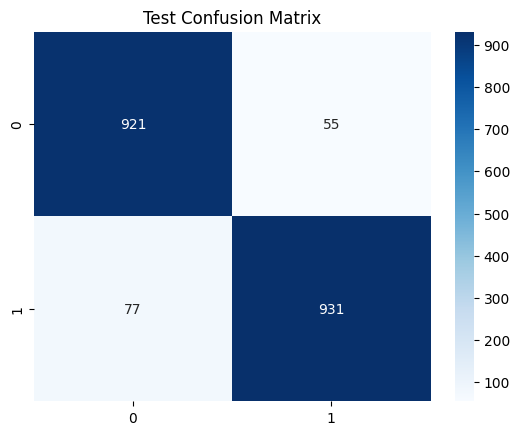

              precision    recall  f1-score   support

  Non-Cancer       0.92      0.94      0.93       976
      Cancer       0.94      0.92      0.93      1008

    accuracy                           0.93      1984
   macro avg       0.93      0.93      0.93      1984
weighted avg       0.93      0.93      0.93      1984



In [36]:
# Confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.savefig('test_cm.png')
plt.show()
print(classification_report(y_true, y_pred, target_names=['Non-Cancer', 'Cancer']))